# ML Kaggle Project - Classification

Pipeline:
1. Data Loading & Preprocessing
2. Feature Engineering & Dimensionality Reduction
3. Learning Algorithms
4. Evaluation
5. Submission

In [6]:
# Imports
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from pathlib import Path

# Chemins cross-platform
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Data Loading & Preprocessing

### 1.1 Chargement et nettoyage de base

Chargement des GeoJSON, conversion CRS, parsing des dates, encodage des catégorielles et de la cible.

In [ ]:
train = gpd.read_file(DATA_DIR / "train.geojson")
test = gpd.read_file(DATA_DIR / "test.geojson")

if 'id' in train.columns: train = train.set_index('id')
if 'id' in test.columns: test = test.set_index('id')

def preprocess_base(df):
    """CRS → EPSG:3857, parse dates, encode categoricals."""
    df = df.to_crs(epsg=3857)
    for col in ['date0', 'date1', 'date2', 'date3', 'date4']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format='%d-%m-%Y')
    if 'urban_type' in df.columns:
        df = pd.get_dummies(df, columns=['urban_type'], prefix='urban', dtype=int)
    if 'geography_type' in df.columns:
        geo_dummies = df['geography_type'].str.get_dummies(sep=',').add_prefix('geo_')
        df = pd.concat([df, geo_dummies], axis=1).drop('geography_type', axis=1)
    return df

train = preprocess_base(train)
test = preprocess_base(test)

change_type_map = {'Demolition': 0, 'Road': 1, 'Residential': 2,
                   'Commercial': 3, 'Industrial': 4, 'Mega Projects': 5}
train['change_type'] = train['change_type'].map(change_type_map)

n_before = len(train)
train = train.dropna()

train.shape, test.shape, n_before - len(train)

✓ Loaded: Train (296146, 45), Test (120526, 44)
✓ Train: 292,758 rows (dropped 3,388, 1.1%)
✓ Test: 120,526 rows (26,010 missing values)
✓ Target distribution:
change_type
0     31156
1     14190
2    146453
3     99500
4      1310
5       149
Name: count, dtype: int64


### 1.2 Tri chronologique par ligne

Les dates (date0–date4) sont en ordre arbitraire dans les données brutes. Pour chaque ligne, on trie les 5 dates par ordre croissant et on réarrange les colonnes associées :
- **t0** (oldest) → **t4** (newest) : dates et status
- Images satellite (date1–date4 uniquement, date0 n'en a pas) réarrangées selon le même ordre
- Images de date5 (sans date associée) gardées comme `img_*_extra`

In [ ]:
def sort_chronologically(df):
    """Trie les dates par ligne: t0 (oldest) → t4 (newest). Réarrange status + images."""
    df = df.copy()
    date_cols = ['date0', 'date1', 'date2', 'date3', 'date4']
    img_bases = ['img_red_mean', 'img_red_std', 'img_green_mean',
                 'img_green_std', 'img_blue_mean', 'img_blue_std']

    dates_int = df[date_cols].values.astype('datetime64[ns]').astype(np.int64)
    nat_mask = df[date_cols].isna().values
    dates_int[nat_mask] = np.iinfo(np.int64).max
    sort_idx = np.argsort(dates_int, axis=1)

    n = len(df)
    rows = np.arange(n)

    dates_np = df[date_cols].values
    for pos in range(5):
        df[f't{pos}_date'] = dates_np[rows, sort_idx[:, pos]]

    status_src = [f'change_status_{c}' for c in date_cols]
    if all(c in df.columns for c in status_src):
        status_np = df[status_src].values
        for pos in range(5):
            df[f'change_status_t{pos}'] = status_np[rows, sort_idx[:, pos]]

    for feat in img_bases:
        feat_arr = np.full((n, 5), np.nan)
        for j, dcol in enumerate(date_cols):
            src = f'{feat}_{dcol}'
            if src in df.columns:
                feat_arr[:, j] = pd.to_numeric(df[src], errors='coerce').values
        for pos in range(5):
            df[f'{feat}_t{pos}'] = feat_arr[rows, sort_idx[:, pos]]

    for feat in img_bases:
        src = f'{feat}_date5'
        if src in df.columns:
            df.rename(columns={src: f'{feat}_extra'}, inplace=True)

    drop = list(date_cols) + list(status_src)
    drop += [f'{feat}_{c}' for feat in img_bases for c in date_cols]
    df = df.drop(columns=[c for c in drop if c in df.columns], errors='ignore')
    return df

train = sort_chronologically(train)
test = sort_chronologically(test)

# Validation: 0 violations attendues
date_sorted_cols = [f't{i}_date' for i in range(5)]
for name, df in [('Train', train), ('Test', test)]:
    sample = df[date_sorted_cols].dropna(how='any').head(1000)
    violations = sum((sample[f't{i}_date'] > sample[f't{i+1}_date']).sum() for i in range(4))
    assert violations == 0, f"{name}: {violations} violations!"

train[date_sorted_cols].head(3)

✓ Train: 0 violations chronologiques sur 1000 lignes
✓ Test: 0 violations chronologiques sur 1000 lignes

Exemple (3 premières lignes train):
     t0_date    t1_date    t2_date    t3_date    t4_date
0 2013-12-09 2016-09-10 2017-07-24 2018-08-01 2019-07-22
1 2013-12-09 2016-09-10 2017-07-24 2018-08-01 2019-07-22
2 2013-12-09 2016-09-10 2017-07-24 2018-08-01 2019-07-22


### 1.3 Feature Engineering (Géométrique + Temporel)

Extraction de features spatiales et temporelles :
- **Géométrie** : aire (m²), périmètre, compacité, centroïde (x, y)
- **Intervalles** : jours entre observations consécutives triées (days_t0_t1, ..., days_t3_t4)
- **Durée totale** : t4 − t0 (positif grâce au tri)
- **Mois** : mois calendaire de chaque observation (month_t0 à month_t4)
- **LabelEncoding** des statuts (change_status_t0 à t4)

In [ ]:
# --- GEOMETRIC FEATURES ---
def extract_geometric_features(gdf):
    """Extract area, perimeter, compactness, centroid."""
    gdf = gdf.copy()
    invalid = ~gdf.geometry.is_valid
    if invalid.any():
        for idx in gdf[invalid].index:
            try: gdf.loc[idx, 'geometry'] = gdf.loc[idx, 'geometry'].make_valid()
            except: gdf.loc[idx, 'geometry'] = None
    empty = gdf.geometry.is_empty | gdf.geometry.isnull()
    if empty.any():
        gdf = gdf[~empty].copy()
    gdf['geom_area'] = gdf.geometry.area
    gdf['geom_perimeter'] = gdf.geometry.length
    with np.errstate(divide='ignore', invalid='ignore'):
        gdf['geom_compactness'] = (4 * np.pi * gdf['geom_area']) / (gdf['geom_perimeter'] ** 2)
    gdf['geom_compactness'] = gdf['geom_compactness'].replace([np.inf, -np.inf], 0).fillna(0)
    centroids = gdf.geometry.centroid
    gdf['geom_centroid_x'] = centroids.x
    gdf['geom_centroid_y'] = centroids.y
    return gdf

train = extract_geometric_features(train)
test = extract_geometric_features(test)

train_geometry = train['geometry'].copy()
test_geometry = test['geometry'].copy()
train = pd.DataFrame(train.drop(columns=['geometry']))
test = pd.DataFrame(test.drop(columns=['geometry']))

# --- TEMPORAL FEATURES ---
date_cols_sorted = [f't{i}_date' for i in range(5)]

for i in range(4):
    train[f'days_t{i}_t{i+1}'] = (train[f't{i+1}_date'] - train[f't{i}_date']).dt.days
    test[f'days_t{i}_t{i+1}'] = (test[f't{i+1}_date'] - test[f't{i}_date']).dt.days

train['total_duration'] = (train['t4_date'] - train['t0_date']).dt.days
test['total_duration'] = (test['t4_date'] - test['t0_date']).dt.days

for i in range(5):
    train[f'month_t{i}'] = train[f't{i}_date'].dt.month
    test[f'month_t{i}'] = test[f't{i}_date'].dt.month

train = train.drop(columns=[c for c in date_cols_sorted if c in train.columns])
test = test.drop(columns=[c for c in date_cols_sorted if c in test.columns])

temporal_features = [f'days_t{i}_t{i+1}' for i in range(4)] + ['total_duration'] + [f'month_t{i}' for i in range(5)]

# --- LABEL ENCODE STATUS ---
status_cols = sorted([c for c in train.columns if c.startswith('change_status_t')])
le_dict = {}
for col in status_cols:
    le = LabelEncoder()
    all_vals = pd.concat([train[col].dropna(), test[col].dropna()]).astype(str).unique()
    le.fit(all_vals)
    for df in [train, test]:
        df[col] = df[col].astype(object)
        mask = df[col].notna()
        df.loc[mask, col] = le.transform(df.loc[mask, col].astype(str))
        df[col] = pd.to_numeric(df[col], errors='coerce')
    le_dict[col] = le

train.shape, test.shape

  ⚠️ Fixing 289 invalid geometries
  ⚠️ Dropping 289 empty geometries
  ⚠️ Fixing 188 invalid geometries
  ⚠️ Dropping 188 empty geometries
✓ Geometric: geom_area, geom_perimeter, geom_compactness, geom_centroid_x/y
✓ Geometry saved (292,469 + 120,338)
✓ Temporal (10): days_t0_t1, days_t1_t2, days_t2_t3, days_t3_t4, total_duration, month_t0, month_t1, month_t2, month_t3, month_t4
✓ LabelEncoded 5 status columns
  Train: (292469, 88), Test: (120338, 87)


### 1.4 Imputation simple (Médiane)

Remplissage des valeurs manquantes avec la médiane calculée sur le train set :
- Images NaN à la position de date0 (pas d'images associées à date0 dans les données brutes)
- ~1.1% de lignes du test avec des valeurs manquantes originales
- Features temporelles dérivées de dates manquantes

In [ ]:
exclude = {'change_type'}
numeric_cols = [c for c in train.select_dtypes(include=[np.number]).columns if c not in exclude]

for col in numeric_cols:
    train[col] = train[col].replace([np.inf, -np.inf], np.nan)
    test[col] = test[col].replace([np.inf, -np.inf], np.nan)
    median_val = train[col].median()
    fill_val = median_val if pd.notna(median_val) else 0
    train[col] = train[col].fillna(fill_val)
    test[col] = test[col].fillna(fill_val)

assert train[numeric_cols].isnull().sum().sum() == 0, "Train has NaN!"
assert test[numeric_cols].isnull().sum().sum() == 0, "Test has NaN!"

train.shape, test.shape

🔧 Imputation — Missing avant: Train=1,754,814, Test=751,203
✓ Imputation — Missing après: Train=0, Test=0


### 1.5 Scaling & Validation finale

Normalisation StandardScaler (fit sur train, transform train + test) et vérification de l'état final.

In [ ]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
features_to_scale = [c for c in numeric_cols if c not in {'change_type', 'index'}]

scaler = StandardScaler()
scaler.fit(train[features_to_scale])
train[features_to_scale] = scaler.transform(train[features_to_scale])
test[features_to_scale] = scaler.transform(test[features_to_scale])

train.to_csv(OUTPUT_DIR / "train_preprocessed.csv", index=True)
test.to_csv(OUTPUT_DIR / "test_preprocessed.csv", index=True)

# Résumé final
summary = pd.DataFrame({
    'Catégorie': ['Images', 'Géométrie', 'Status', 'Temporel', 'Urban', 'Géo', 'Target', 'TOTAL'],
    'Colonnes': [
        len([c for c in train.columns if c.startswith('img_')]),
        len([c for c in train.columns if c.startswith('geom_')]),
        len([c for c in train.columns if c.startswith('change_status_')]),
        len([c for c in train.columns if c.startswith('days_') or c.startswith('month_') or c == 'total_duration']),
        len([c for c in train.columns if c.startswith('urban_')]),
        len([c for c in train.columns if c.startswith('geo_')]),
        int('change_type' in train.columns),
        len(train.columns)
    ]
}).set_index('Catégorie')
display(summary)
train.shape, test.shape

✓ Scaled 86 features

ÉTAT FINAL DU PREPROCESSING

📊 Shapes: Train (292469, 88), Test (120338, 87)
   Geometry saved: 292,469 + 120,338

🔢 Missing: Train=0, Test=0

🎯 Features:
  Images (img_): 36
  Geometric (geom_): 5
  Status (change_status_): 5
  Urban (urban_): 17
  Geographic (geo_): 13
  Temporal: 10
  Target: True
  Total: 88

✅ Preprocessing complet!


## 2. Feature Engineering & Dimensionality Reduction

### 2.1 Analyse de corrélation

Identification des features redondantes (|r| > 0.9) et des features les plus discriminantes par rapport à la target. Pour chaque paire fortement corrélée, on supprime celle qui corrèle le moins avec `change_type`.

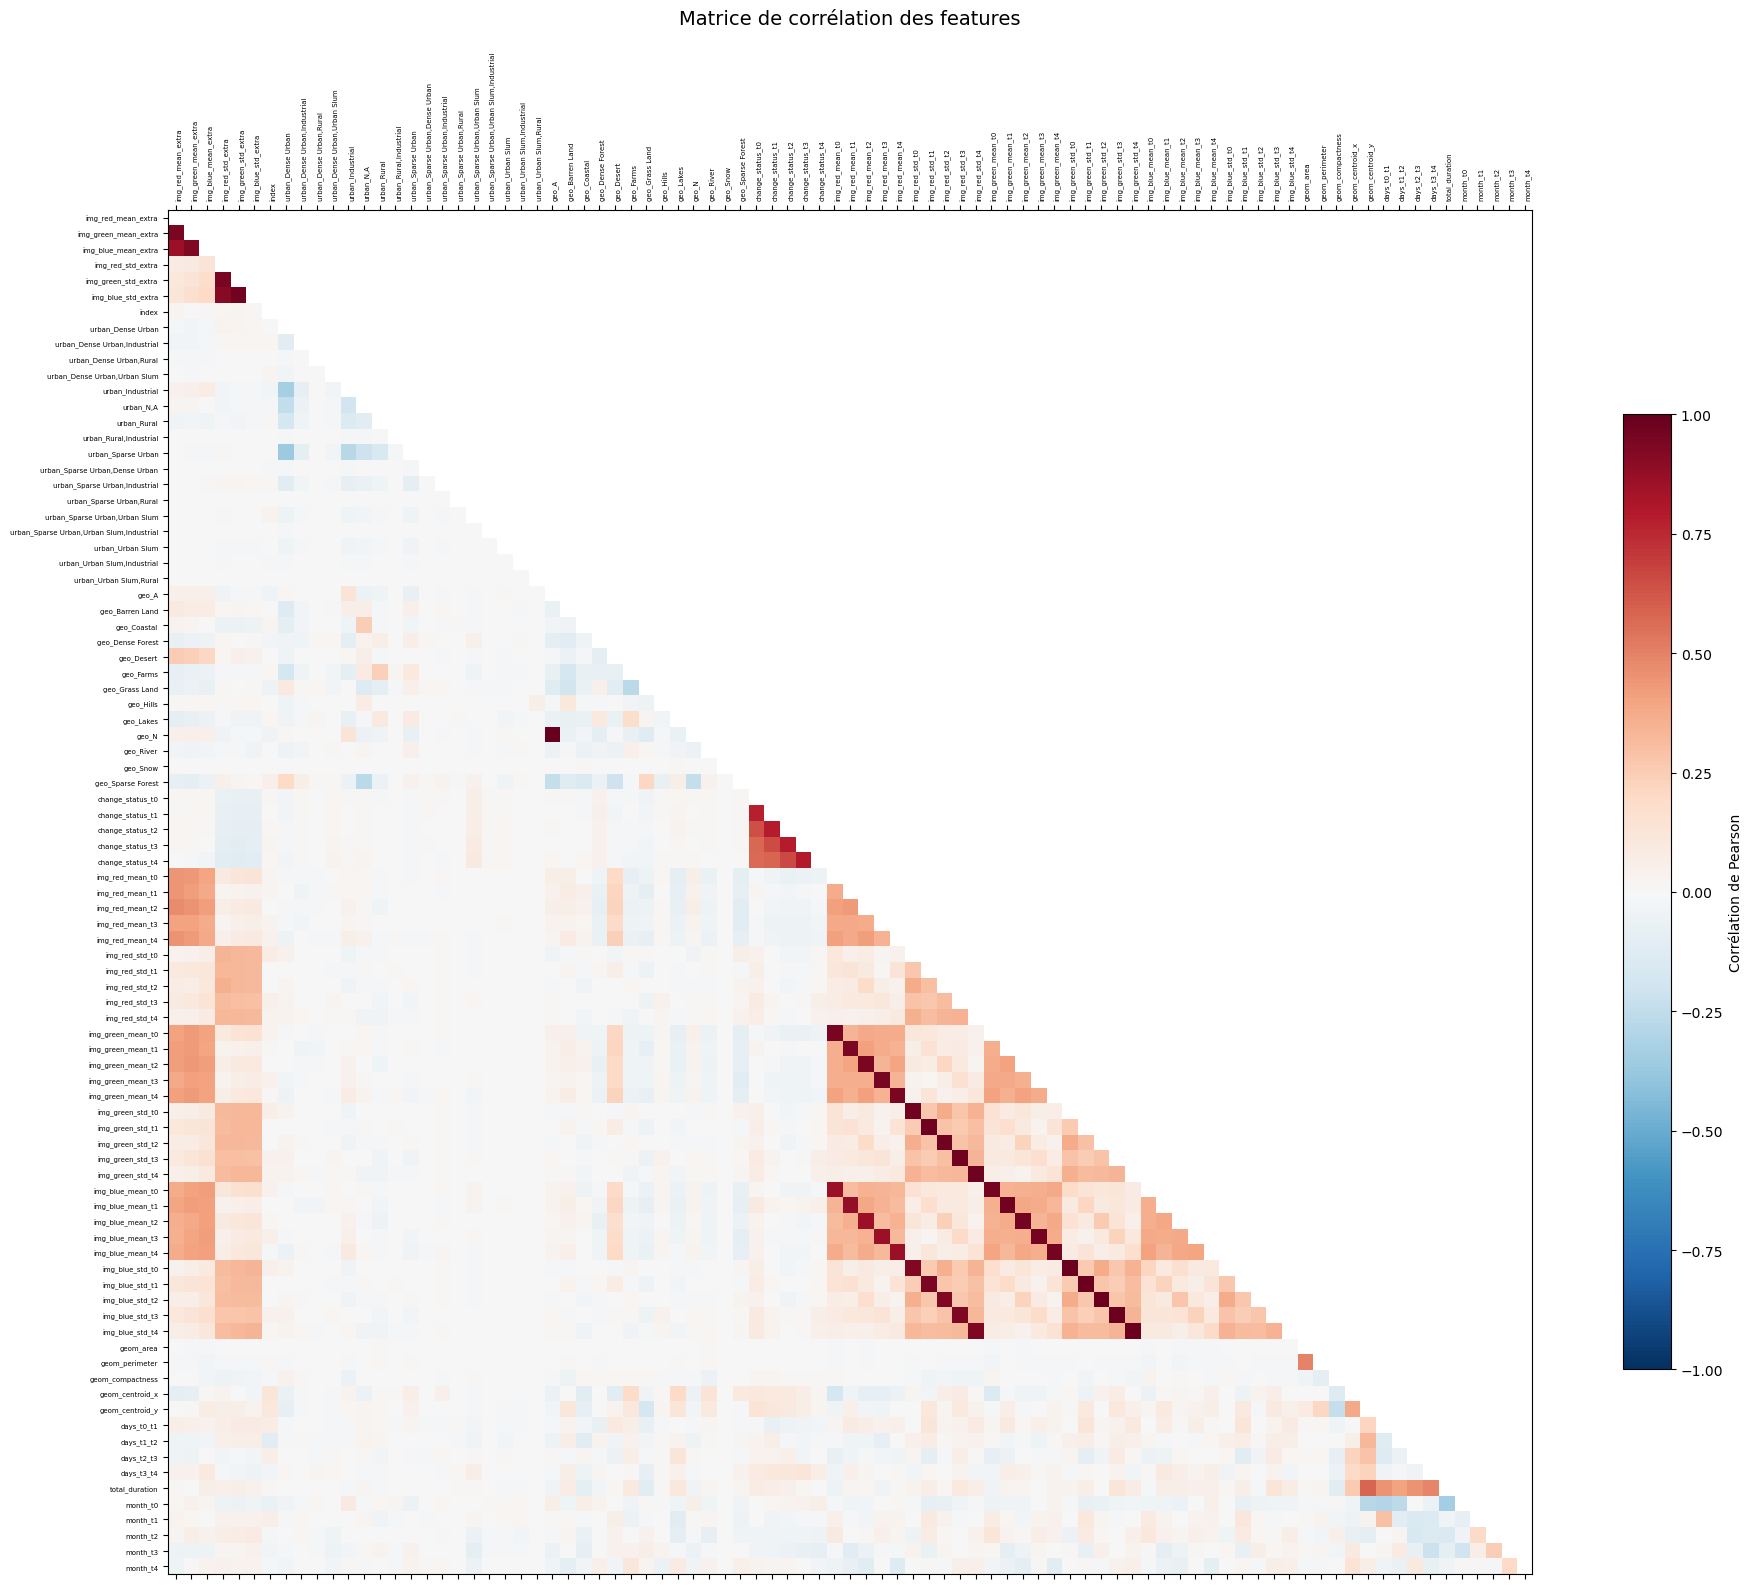

,Feature 1,Feature 2,r
5,geo_A,geo_N,1.000
27,img_green_std_t1,img_blue_std_t1,0.981
30,img_green_std_t4,img_blue_std_t4,0.980
28,img_green_std_t2,img_blue_std_t2,0.978
29,img_green_std_t3,img_blue_std_t3,0.977
26,img_green_std_t0,img_blue_std_t0,0.977
13,img_red_std_t1,img_green_std_t1,0.973
19,img_red_std_t4,img_green_std_t4,0.970
17,img_red_std_t3,img_green_std_t3,0.969
15,img_red_std_t2,img_green_std_t2,0.967


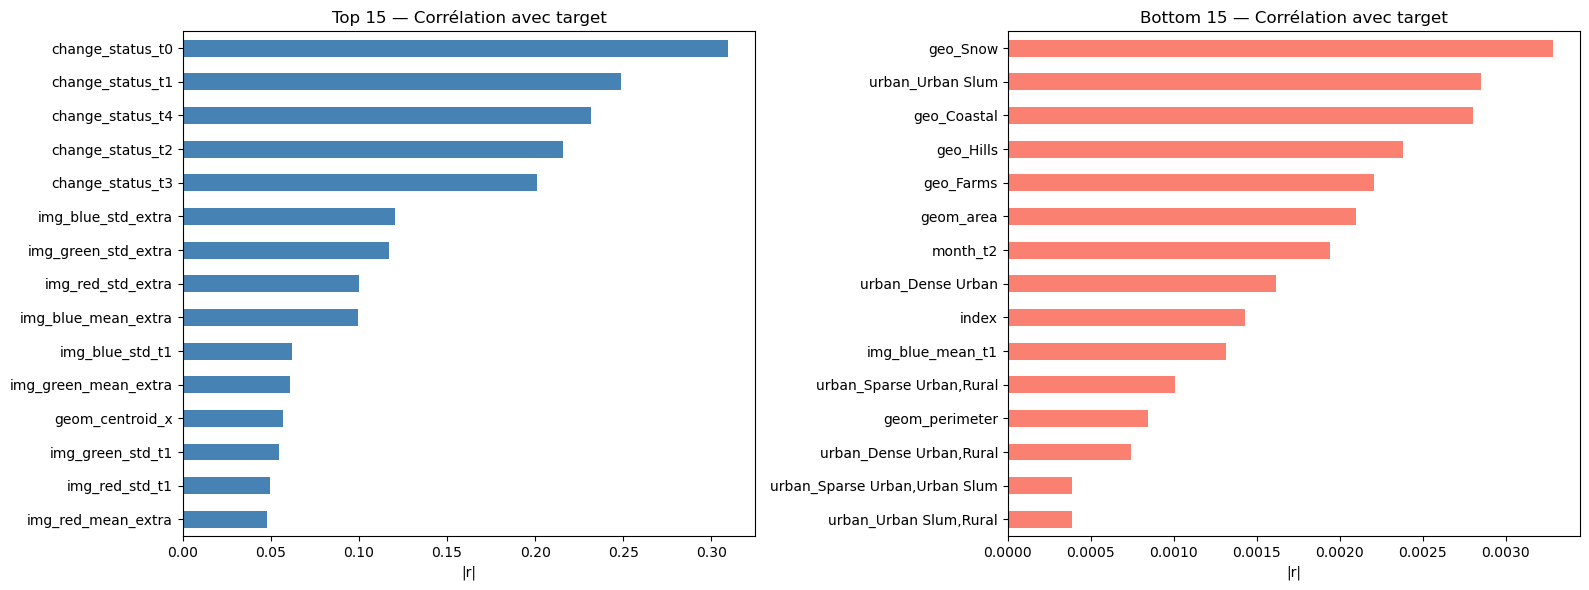

,Features supprimées
0,geo_N
1,img_green_mean_extra
2,img_green_mean_t0
3,img_green_mean_t1
4,img_green_mean_t2
5,img_green_mean_t3
6,img_green_mean_t4
7,img_green_std_extra
8,img_green_std_t0
9,img_green_std_t1


In [17]:
target = train['change_type']
features = train.drop(columns=['change_type'])
feature_names = features.columns.tolist()

corr_matrix = features.corr()

# --- HEATMAP ---
fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cax = ax.matshow(corr_matrix.where(~mask).values, cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(cax, ax=ax, shrink=0.7, label='Corrélation de Pearson')
ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=90, fontsize=5, ha='left')
ax.set_yticklabels(feature_names, fontsize=5)
ax.set_title('Matrice de corrélation des features', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# --- PAIRES FORTEMENT CORRÉLÉES ---
threshold = 0.9
high_corr = []
for i in range(len(corr_matrix)):
    for j in range(i + 1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > threshold:
            high_corr.append((feature_names[i], feature_names[j], round(r, 3)))

corr_with_target = features.corrwith(target).abs().sort_values(ascending=False)

pairs_df = pd.DataFrame(high_corr, columns=['Feature 1', 'Feature 2', 'r']).sort_values('r', key=abs, ascending=False)
display(pairs_df)

# --- TOP / BOTTOM CORRÉLATIONS AVEC TARGET ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_with_target.head(15).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 — Corrélation avec target')
axes[0].set_xlabel('|r|')
axes[0].invert_yaxis()

corr_with_target.tail(15).plot.barh(ax=axes[1], color='salmon')
axes[1].set_title('Bottom 15 — Corrélation avec target')
axes[1].set_xlabel('|r|')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_target.png", dpi=150, bbox_inches='tight')
plt.show()

# --- DROP FEATURES REDONDANTES ---
to_drop = set()
for f1, f2, r in high_corr:
    if f1 in to_drop or f2 in to_drop:
        continue
    r1 = corr_with_target.get(f1, 0)
    r2 = corr_with_target.get(f2, 0)
    to_drop.add(f2 if r1 >= r2 else f1)

train = train.drop(columns=list(to_drop))
test = test.drop(columns=list(to_drop))

pd.DataFrame({'Features supprimées': sorted(to_drop)})

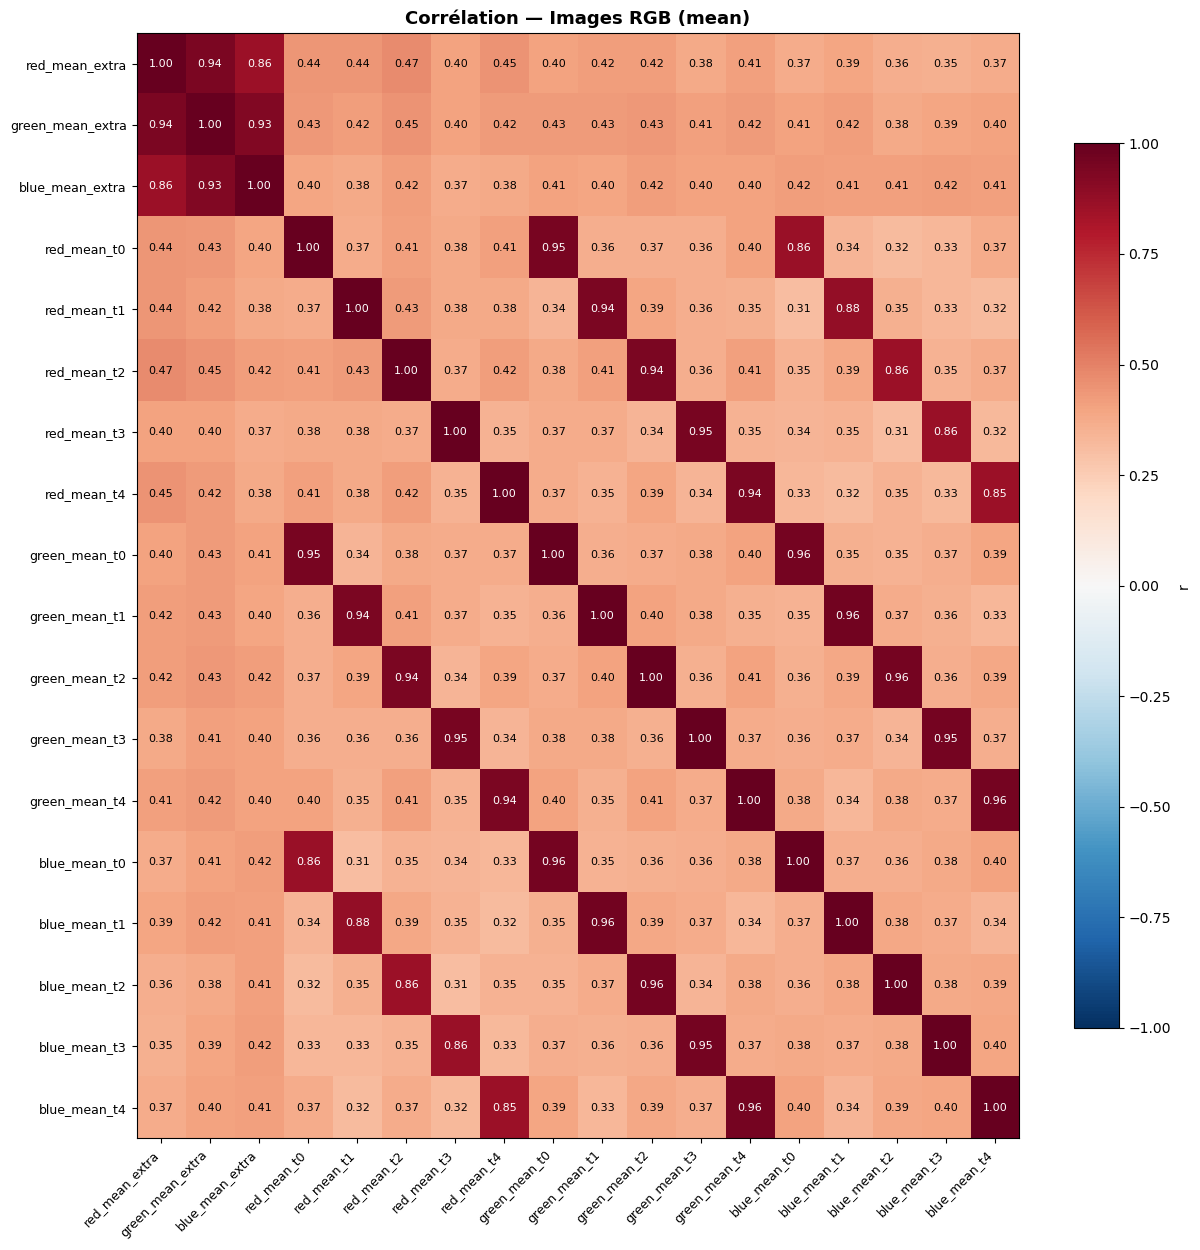

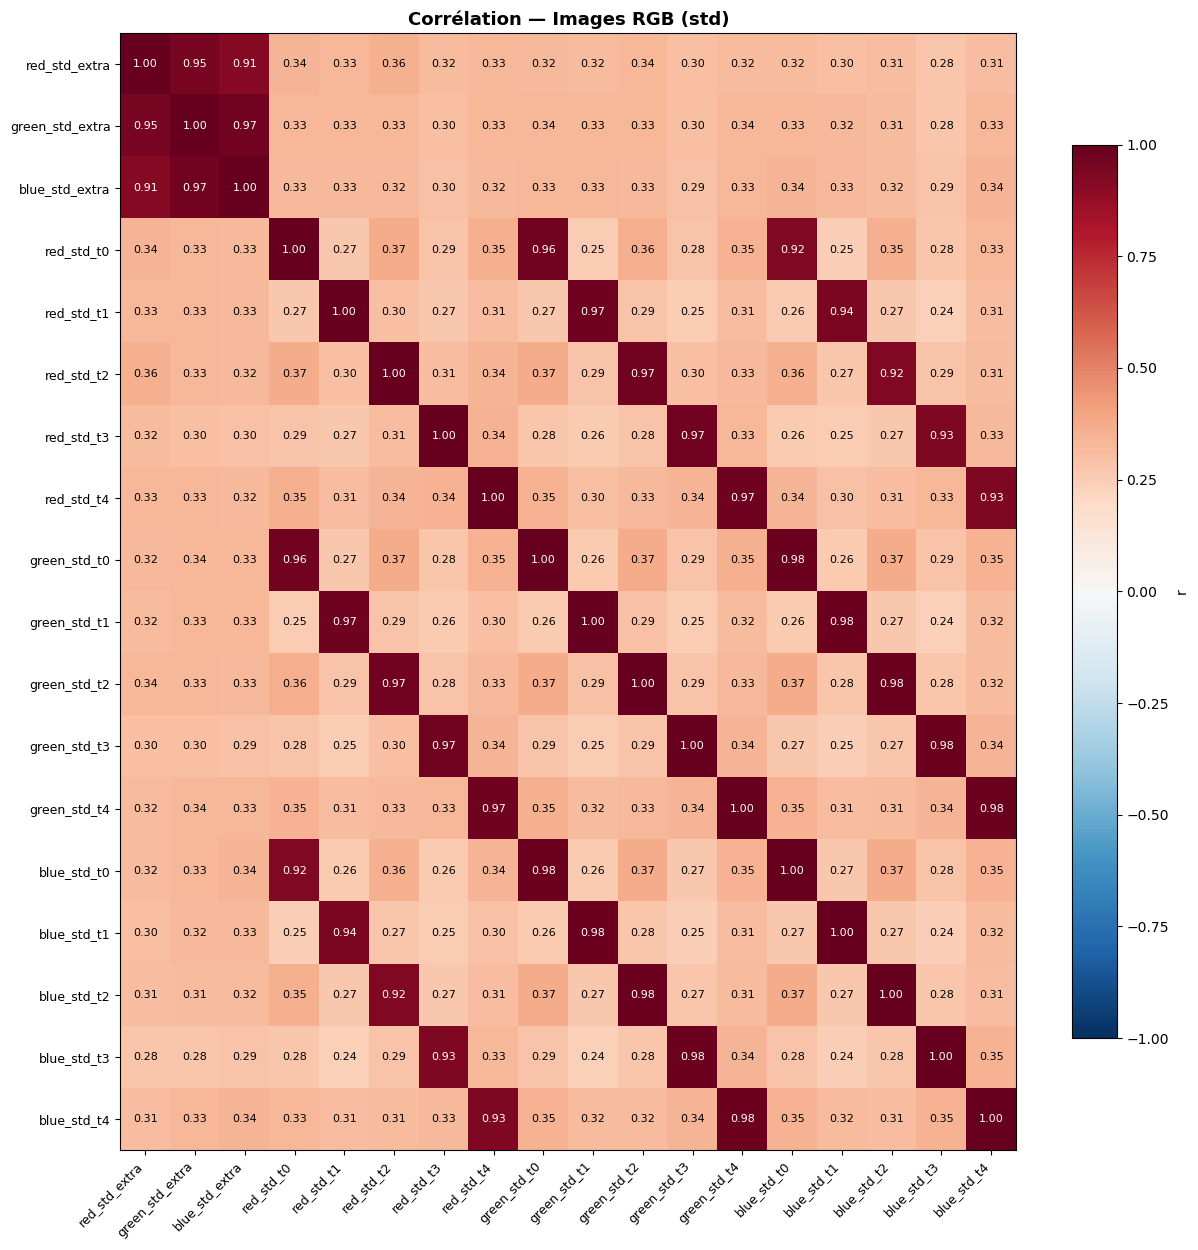

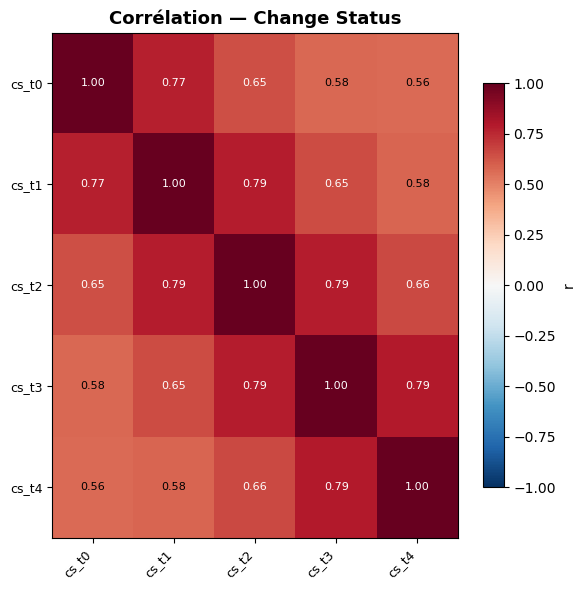

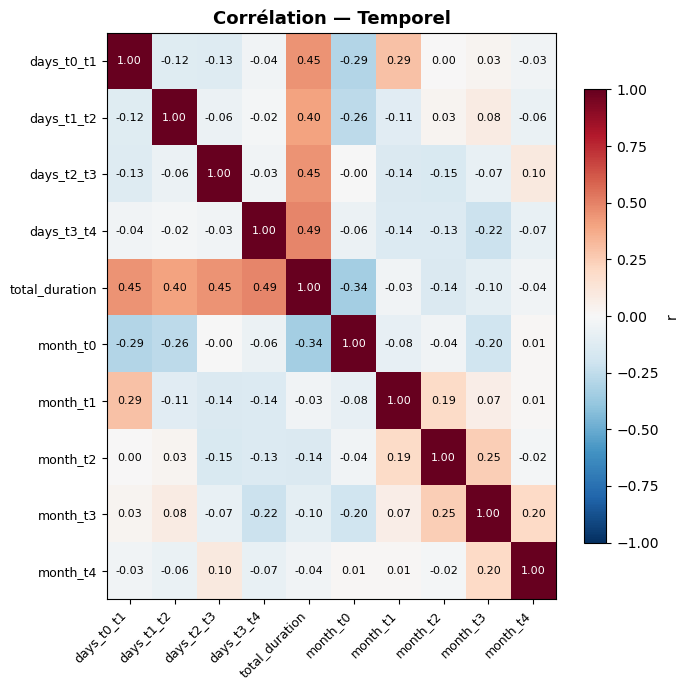

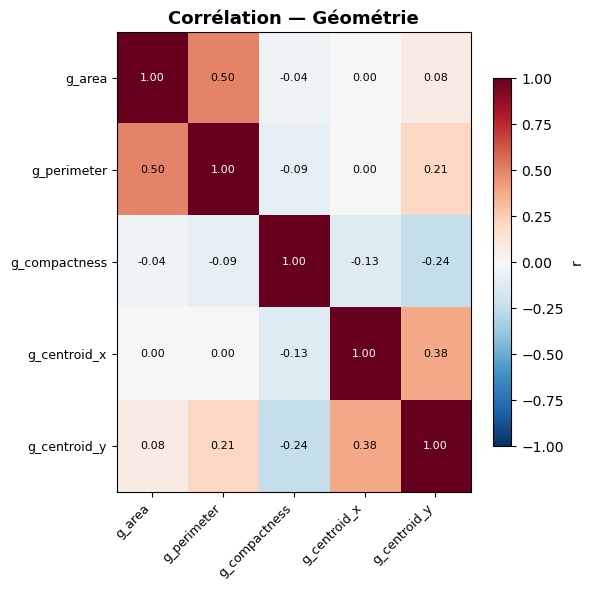

In [19]:
# Sous-matrices de corrélation — une figure par groupe
groups = {
    'Images RGB (mean)': [c for c in feature_names if 'mean' in c and c.startswith('img_')],
    'Images RGB (std)':  [c for c in feature_names if 'std' in c and c.startswith('img_')],
    'Change Status':     [c for c in feature_names if c.startswith('change_status_')],
    'Temporel':          [c for c in feature_names if c.startswith('days_') or c.startswith('month_') or c == 'total_duration'],
    'Géométrie':         [c for c in feature_names if c.startswith('geom_')],
}
groups = {k: v for k, v in groups.items() if len(v) >= 2}

for gname, gcols in groups.items():
    sub_corr = corr_matrix.loc[gcols, gcols]
    n = len(gcols)
    size = max(6, n * 0.7)
    
    fig, ax = plt.subplots(figsize=(size, size))
    im = ax.imshow(sub_corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    
    for i in range(n):
        for j in range(n):
            val = sub_corr.iloc[i, j]
            color = 'white' if abs(val) > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)
    
    short = [c.replace('img_', '').replace('change_status_', 'cs_').replace('geom_', 'g_') for c in gcols]
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(short, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(short, fontsize=9)
    ax.set_title(f'Corrélation — {gname}', fontsize=13, fontweight='bold')
    fig.colorbar(im, ax=ax, shrink=0.8, label='r')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"corr_{gname.replace(' ', '_').replace('(', '').replace(')', '')}.png", dpi=150, bbox_inches='tight')
    plt.show()

### 2.2 Feature Selection — Importance & Mutual Information

Sélection des features les plus discriminantes via deux méthodes complémentaires :
1. **Random Forest Feature Importance** : capture les relations non-linéaires entre features et target
2. **Mutual Information** : mesure la dépendance statistique feature↔target (sans hypothèse de linéarité)
3. **Score combiné** : moyenne des deux rankings → sélection des top-K features (75%)

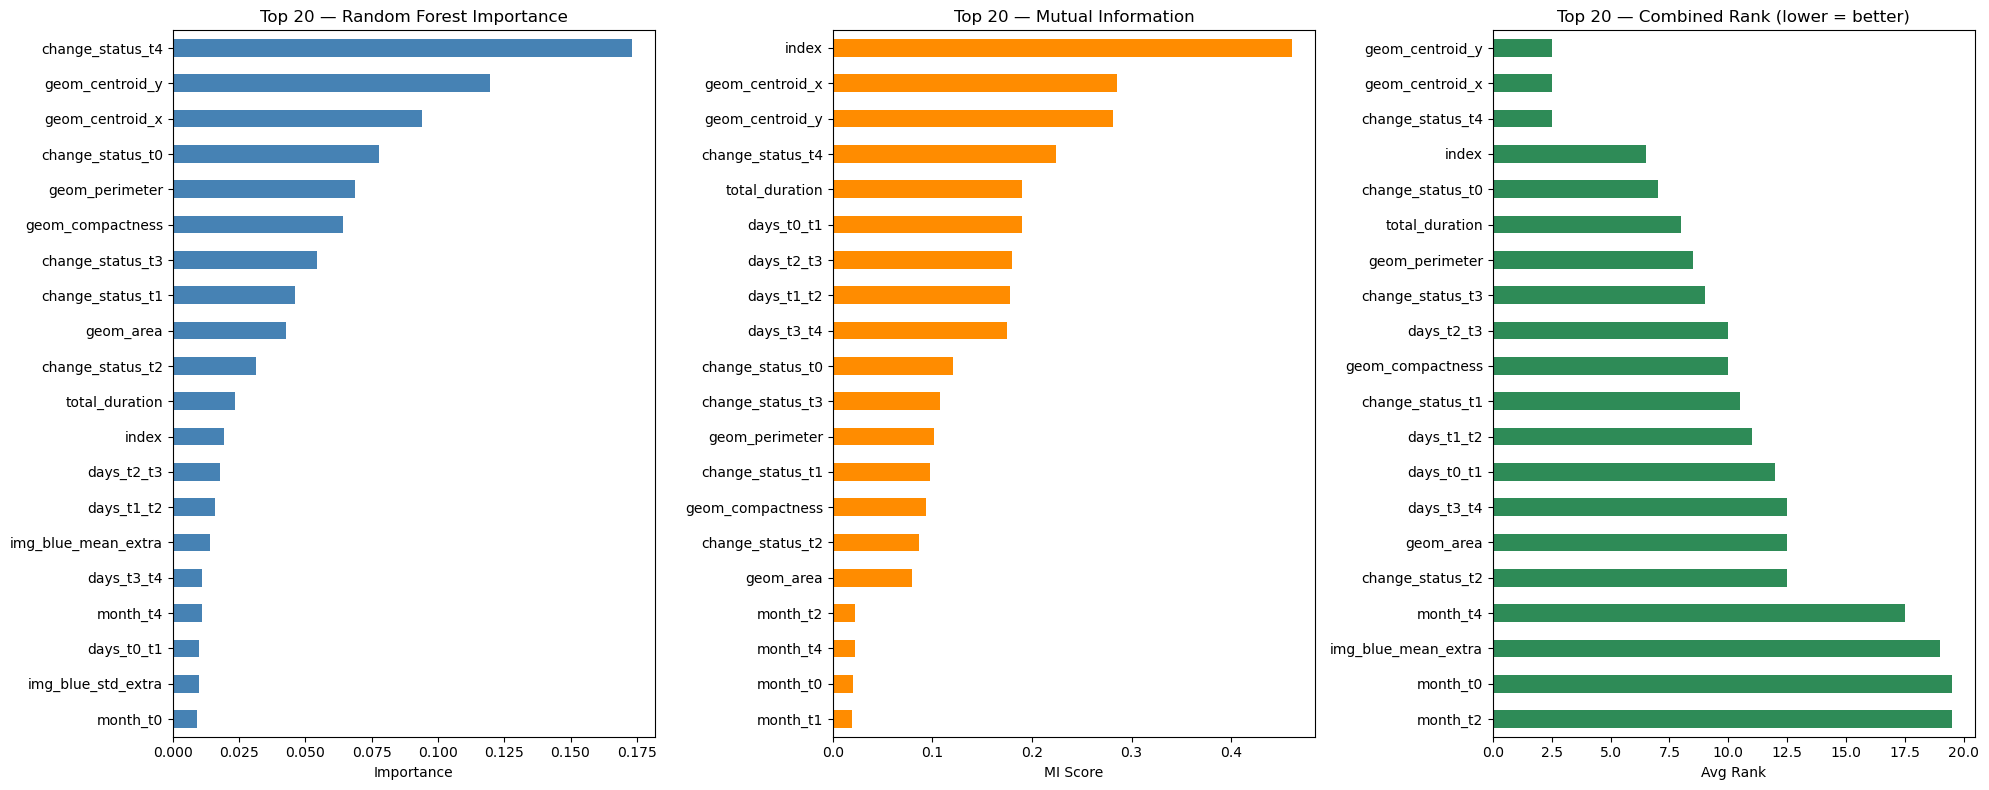

,Feature,RF Importance,Mutual Info,Combined Rank,Kept
56,geom_centroid_y,1.196567e-01,0.281819,2.50,✓
55,geom_centroid_x,9.391996e-02,0.285796,2.50,✓
36,change_status_t4,1.731914e-01,0.223911,2.50,✓
2,index,1.927686e-02,0.461185,6.50,✓
32,change_status_t0,7.776937e-02,0.120764,7.00,✓
...,...,...,...,...,...
10,"urban_Rural,Industrial",5.553411e-06,0.000000,63.25,✗
16,"urban_Sparse Urban,Urban Slum,Industrial",7.977858e-07,0.000000,64.25,✗
5,"urban_Dense Urban,Rural",0.000000e+00,0.000003,64.50,✗
14,"urban_Sparse Urban,Rural",5.337826e-07,0.000000,64.75,✗


,Valeur
Métrique,
Features avant sélection,67
Features retenues,50
Features supprimées,17


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

# Séparer features / target
X_train = train.drop(columns=['change_type'])
y_train = train['change_type']
X_test = test.copy()
feature_cols = X_train.columns.tolist()

# --- 1. Random Forest Feature Importance ---
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_importance = pd.Series(rf.feature_importances_, index=feature_cols, name='RF Importance')

# --- 2. Mutual Information ---
mi_scores = mutual_info_classif(X_train, y_train, random_state=42, n_neighbors=5)
mi_importance = pd.Series(mi_scores, index=feature_cols, name='Mutual Info')

# --- 3. Score combiné (rank moyen) ---
rf_rank = rf_importance.rank(ascending=False)
mi_rank = mi_importance.rank(ascending=False)
combined_rank = ((rf_rank + mi_rank) / 2).sort_values()
combined_rank.name = 'Combined Rank'

# --- Visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

rf_importance.sort_values(ascending=True).tail(20).plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 — Random Forest Importance')
axes[0].set_xlabel('Importance')

mi_importance.sort_values(ascending=True).tail(20).plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title('Top 20 — Mutual Information')
axes[1].set_xlabel('MI Score')

combined_rank.sort_values(ascending=False).tail(20).plot.barh(ax=axes[2], color='seagreen')
axes[2].set_title('Top 20 — Combined Rank (lower = better)')
axes[2].set_xlabel('Avg Rank')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_selection.png", dpi=150, bbox_inches='tight')
plt.show()

# --- 4. Sélection : garder le top 75% ---
k = int(len(feature_cols) * 0.75)
selected_features = combined_rank.head(k).index.tolist()
dropped_features = combined_rank.tail(len(feature_cols) - k).index.tolist()

train = train[selected_features + ['change_type']]
test = test[selected_features]

# Préparer X/y pour la section 3
X_train = train.drop(columns=['change_type'])
y_train = train['change_type']
X_test = test.copy()

# Résumé
summary_df = pd.DataFrame({
    'Feature': feature_cols,
    'RF Importance': rf_importance[feature_cols].values,
    'Mutual Info': mi_importance[feature_cols].values,
    'Combined Rank': combined_rank[feature_cols].values,
    'Kept': ['✓' if f in selected_features else '✗' for f in feature_cols]
}).sort_values('Combined Rank')
display(summary_df)

pd.DataFrame({
    'Métrique': ['Features avant sélection', 'Features retenues', 'Features supprimées'],
    'Valeur': [len(feature_cols), len(selected_features), len(dropped_features)]
}).set_index('Métrique')

## 3. Learning Algorithms

### 3.1 Diagnostic du déséquilibre de classes

Visualisation de la distribution des classes et calcul du ratio de déséquilibre. Les poids de classe seront utilisés pour compenser lors de l'entraînement.

In [ ]:
# --- Diagnostic du déséquilibre de classes ---
class_names = {0: 'Demolition', 1: 'Road', 2: 'Residential',
               3: 'Commercial', 4: 'Industrial', 5: 'Mega Projects'}

class_counts = y_train.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts.rename(class_names).plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Distribution des classes (absolue)')
axes[0].set_ylabel("Nombre d'échantillons")
axes[0].tick_params(axis='x', rotation=45)

(class_counts / len(y_train) * 100).rename(class_names).plot.bar(ax=axes[1], color='darkorange')
axes[1].set_title('Distribution des classes (%)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# Calcul des poids de classe pour XGBoost
from sklearn.utils.class_weight import compute_class_weight

classes = np.sort(y_train.unique())
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
sample_weights = y_train.map(class_weight_dict).values

print(f"Ratio max/min : {class_counts.max() / class_counts.min():.1f}x\n")
print("Détail :")
for idx, count in class_counts.items():
    print(f"  {class_names[idx]:15s} : {count:6d} ({count/len(y_train)*100:5.1f}%)  →  poids = {class_weight_dict[idx]:.3f}")

Learning algorithms: TODO


### 3.2 XGBoost avec poids de classes

Entraînement d'un XGBoost multi-classe (`multi:softprob`) avec `sample_weight` pour compenser le déséquilibre. Évaluation par cross-validation stratifiée (5 folds) avec métriques sensibles au déséquilibre :
- **F1 macro** : moyenne non pondérée → chaque classe compte autant
- **F1 weighted** : pondéré par le support
- **Classification report** : precision/recall/F1 par classe
- **Matrice de confusion** : visualisation des erreurs inter-classes

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)

# --- XGBoost avec sample_weight ---
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=6,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation avec F1 macro et weighted
f1_macro_scores = cross_val_score(xgb, X_train, y_train, cv=cv,
                                  scoring='f1_macro', fit_params={'sample_weight': sample_weights})
f1_weighted_scores = cross_val_score(xgb, X_train, y_train, cv=cv,
                                     scoring='f1_weighted', fit_params={'sample_weight': sample_weights})
accuracy_scores = cross_val_score(xgb, X_train, y_train, cv=cv,
                                  scoring='accuracy', fit_params={'sample_weight': sample_weights})

print("=== XGBoost — Cross-Validation (5 folds, class-weighted) ===\n")
print(f"  Accuracy       : {accuracy_scores.mean():.4f} ± {accuracy_scores.std():.4f}")
print(f"  F1 macro       : {f1_macro_scores.mean():.4f} ± {f1_macro_scores.std():.4f}")
print(f"  F1 weighted    : {f1_weighted_scores.mean():.4f} ± {f1_weighted_scores.std():.4f}")

# Cross-val predictions pour matrice de confusion
y_pred_cv = cross_val_predict(xgb, X_train, y_train, cv=cv,
                              fit_params={'sample_weight': sample_weights})

# --- Classification Report ---
print("\n=== Classification Report (cross-validation) ===\n")
print(classification_report(y_train, y_pred_cv,
                            target_names=list(class_names.values()), digits=3))

# --- Matrice de confusion ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Absolue
cm = confusion_matrix(y_train, y_pred_cv)
disp = ConfusionMatrixDisplay(cm, display_labels=list(class_names.values()))
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matrice de confusion (absolue)')
axes[0].tick_params(axis='x', rotation=45)

# Normalisée par ligne (recall par classe)
cm_norm = confusion_matrix(y_train, y_pred_cv, normalize='true')
disp_norm = ConfusionMatrixDisplay(cm_norm, display_labels=list(class_names.values()))
disp_norm.plot(ax=axes[1], cmap='Oranges', values_format='.2f')
axes[1].set_title('Matrice de confusion (normalisée — recall)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_xgb.png", dpi=150, bbox_inches='tight')
plt.show()

# --- F1 par classe (barplot) ---
report = classification_report(y_train, y_pred_cv,
                               target_names=list(class_names.values()), output_dict=True)
f1_per_class = pd.Series({k: v['f1-score'] for k, v in report.items() if k in class_names.values()})

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#e74c3c' if v < 0.5 else '#f39c12' if v < 0.7 else '#2ecc71' for v in f1_per_class.values]
f1_per_class.plot.bar(ax=ax, color=colors_bar, edgecolor='black', linewidth=0.5)
ax.axhline(0.5, color='red', ls='--', alpha=0.5, label='Seuil faible (0.5)')
ax.axhline(f1_macro_scores.mean(), color='blue', ls='--', alpha=0.7, label=f'F1 macro = {f1_macro_scores.mean():.3f}')
ax.set_title('F1-score par classe (XGBoost weighted)')
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1)
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "f1_per_class_xgb.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Entraîner le modèle final sur tout le train ---
xgb.fit(X_train, y_train, sample_weight=sample_weights)
print(f"\nModèle final entraîné sur {len(X_train)} échantillons, {X_train.shape[1]} features.")

Evaluation: TODO


## 5. Submission

Generate predictions and export to CSV for Kaggle submission.

In [ ]:
# Prédictions sur le test set
change_type_inv = {v: k for k, v in change_type_map.items()}

y_test_pred = xgb.predict(X_test)
y_test_labels = pd.Series(y_test_pred, index=X_test.index).map(change_type_inv)

submission = pd.DataFrame({'change_type': y_test_labels}, index=X_test.index)
submission.index.name = 'id'
submission.to_csv(OUTPUT_DIR / "submission.csv")

# Distribution des prédictions
pred_counts = y_test_labels.value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
pred_counts.plot.bar(ax=ax, color='steelblue')
ax.set_title('Distribution des prédictions (test set)')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

display(submission.head(10))
print(f"\nSubmission sauvegardée : {OUTPUT_DIR / 'submission.csv'} ({len(submission)} lignes)")

Submission: TODO
